<a href="https://colab.research.google.com/github/dhunsyam/Advance-Databases/blob/gh-pages/notebooks/01.00-Elbow%20and%20silhouette%20methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Jupyter: Beyond Normal Python

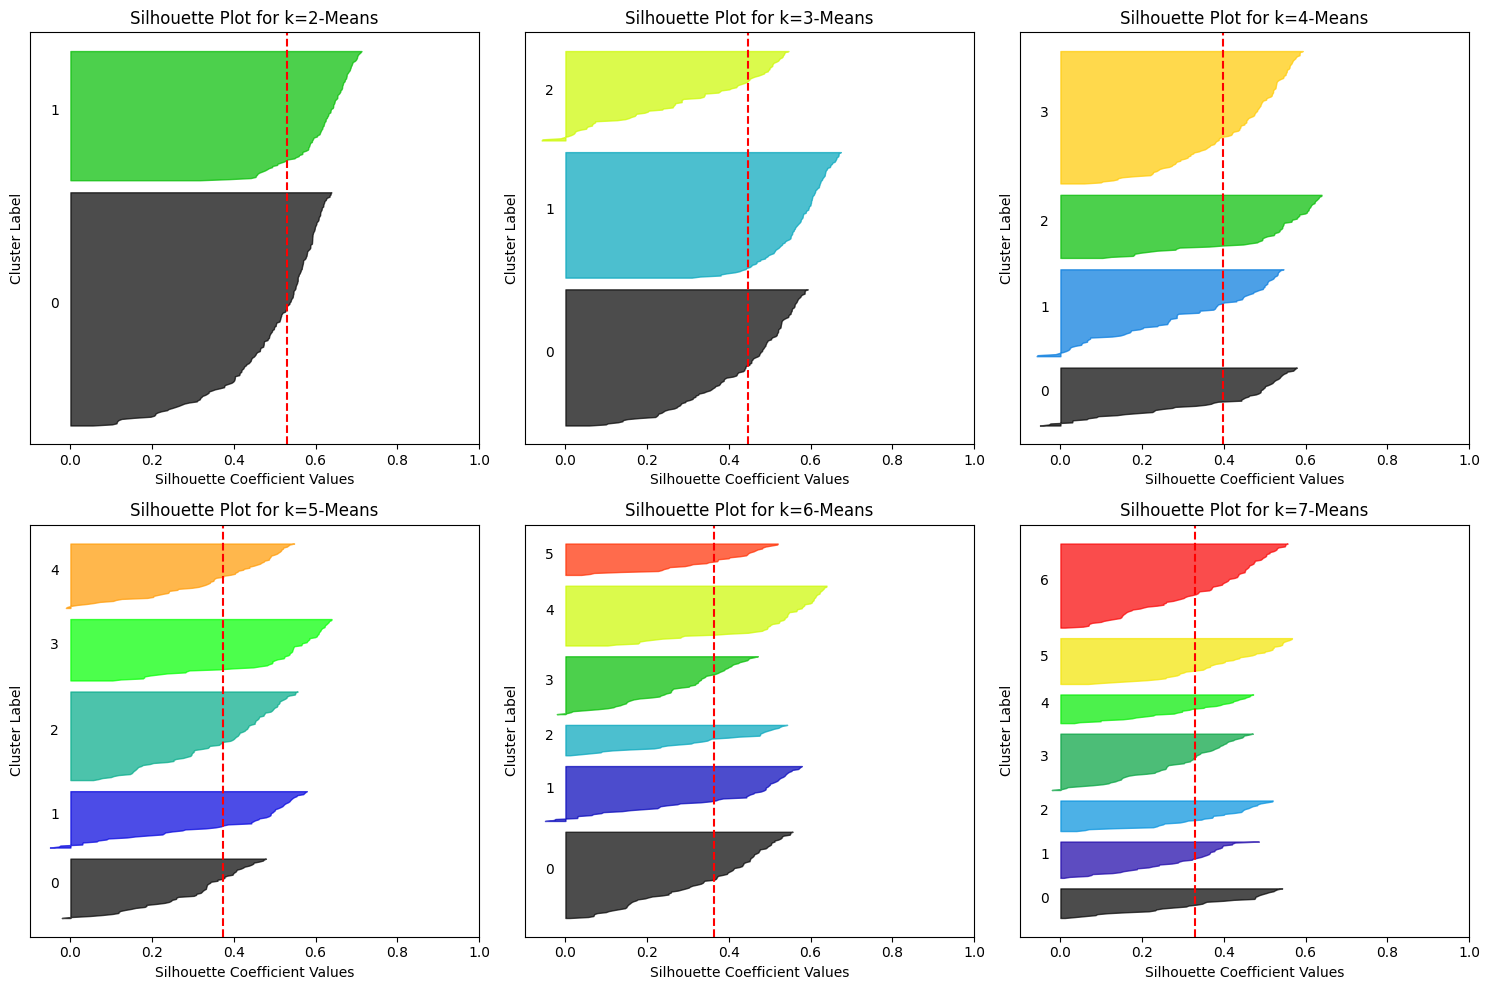

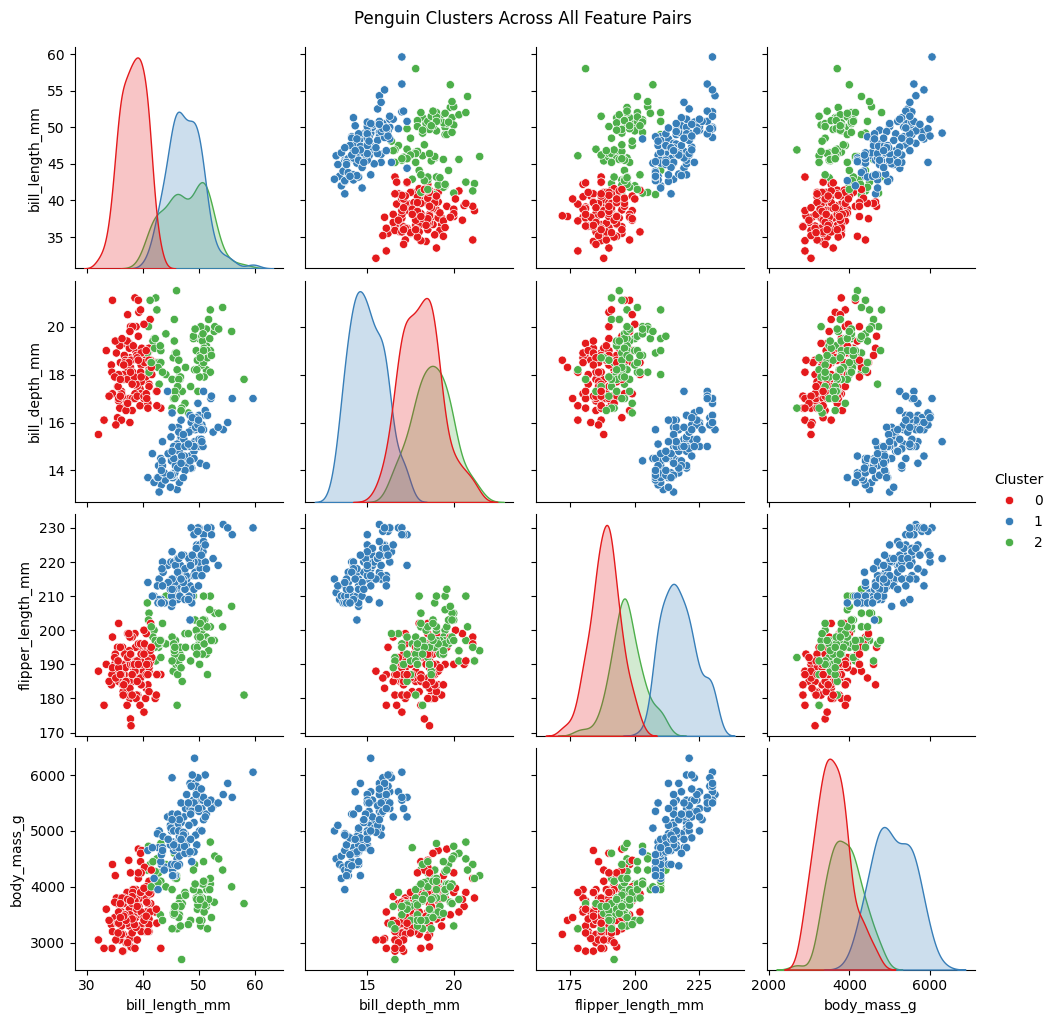

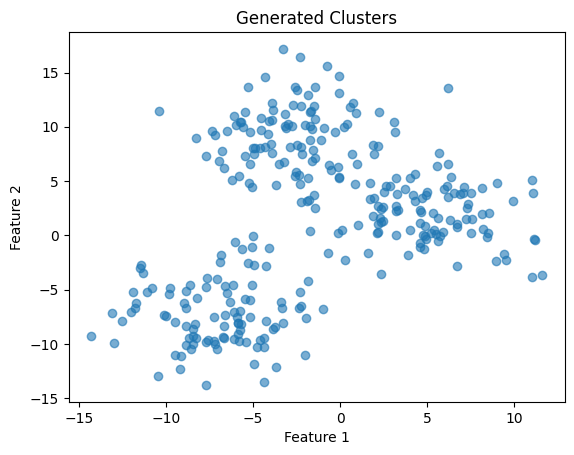

In [6]:
import numpy as np

import matplotlib.pyplot as plt

import matplotlib.cm as cm

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_samples



#Define optimal k from previous analysis

k_range = range(2, 8)

#Create a grid of subplots

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))  # Adjust rows and columns as needed

axes = axes.flatten()  # Flatten the 2D array of axes for easy indexing



#Loop through the values of k and plot the silhouette scores

for idx, k in enumerate(k_range):

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    cluster_labels = kmeans.fit_predict(X_scaled)



    # Compute silhouette scores for each sample

    silhouette_vals = silhouette_samples(X_scaled, cluster_labels)



    # Get the current axis for the subplot

    ax = axes[idx]



    # Initialize y_lower to track position for each cluster's silhouette

    y_lower = 10



    for i in range(k):

        # Extract silhouette scores for cluster i

        cluster_silhouette_vals = silhouette_vals[cluster_labels == i]

        cluster_silhouette_vals.sort()

        size_cluster_i = cluster_silhouette_vals.shape[0]

        y_upper = y_lower + size_cluster_i



        # Fill in the silhouette plot

        color = cm.nipy_spectral(float(i) / k)

        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals, facecolor=color, edgecolor=color, alpha=0.7)



        # Label cluster number in the middle of each section

        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))



        # Update y_lower for the next cluster

        y_lower = y_upper + 10



    # Format the plot

    ax.set_xlabel("Silhouette Coefficient Values")

    ax.set_ylabel("Cluster Label")

    ax.set_title(f"Silhouette Plot for k={k}-Means")

    ax.axvline(x=np.mean(silhouette_vals), color="red", linestyle="--")  # Mean silhouette score

    ax.set_yticks([])  # Remove y-axis ticks

    ax.set_xlim([-0.1, 1])  # Standard silhouette range



#Adjust the layout to prevent overlap

plt.tight_layout()

plt.show()







# Apply K-Means with k=3

optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(X_scaled)



import seaborn as sns

import matplotlib.pyplot as plt



#Pairplot of all features colored by cluster

sns.pairplot(df, hue="Cluster", palette="Set1", diag_kind="kde")

plt.suptitle("Penguin Clusters Across All Feature Pairs", y=1.02)

plt.show()






from sklearn.datasets import make_blobs

import pandas as pd

import matplotlib.pyplot as plt



#Generate 300 samples with 3 clusters

X, y = make_blobs(n_samples=300, centers=3, cluster_std=3.0, random_state=42)

#Convert to a DataFrame

df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

#Plot the dataset

plt.scatter(df['Feature_1'], df['Feature_2'], alpha=0.6)

plt.xlabel('Feature 1')

plt.ylabel('Feature 2')

plt.title('Generated Clusters')

plt.show()

There are many options for development environments for Python, and I'm often asked which one I use in my own work.
My answer sometimes surprises people: my preferred environment is [IPython](http://ipython.org/) plus a text editor (in my case, Emacs or VSCode depending on my mood).
Jupyter got its start as the IPython shell, which was created in 2001 by Fernando Perez as an enhanced Python interpreter and has since grown into a project aiming to provide, in Perez's words, "Tools for the entire life cycle of research computing."
If Python is the engine of our data science task, you might think of Jupyter as the interactive control panel.

As well as being a useful interactive interface to Python, Jupyter also provides a number of useful syntactic additions to the language; we'll cover the most useful of these additions here.
Perhaps the most familiar interface provided by the Jupyter project is the Jupyter Notebook, a browser-based environment that is useful for development, collaboration, sharing, and even publication of data science results.
As an example of the usefulness of the notebook format, look no further than the page you are reading: the entire manuscript for this book was composed as a set of Jupyter notebooks.

This part of the book will start by stepping through some of the Jupyter and IPython features that are useful to the practice of data science, focusing especially on the syntax they offer beyond the standard features of Python.
Next, we will go into a bit more depth on some of the more useful *magic commands* that can speed up common tasks in creating and using data science code.
Finally, we will touch on some of the features of the notebook that make it useful for understanding data and sharing results.